<a href="https://colab.research.google.com/github/abteenasgharian/crude-pulse-analysis/blob/main/Crude_Pulse_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **The Global Crude Pulse: Brent vs. WTI Benchmark Analysis**

In [4]:
# import libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [11]:
# Download Live Database

wti = yf.download("CL=F", period="5d", interval="1m", progress=False, auto_adjust = True)
brent = yf.download("BZ=F", period="5d", interval="1m", progress=False, auto_adjust = True)

# Combine Prices into Table
prices = pd.concat([wti['Close'], brent['Close']], axis=1).ffill().dropna()
prices.columns = ['WTI', 'Brent']

print("Clean Data Pulse:")
display(prices.head())

Clean Data Pulse:


,WTI,Brent
Datetime,,
2026-04-22 04:06:00+00:00,89.220001,92.769997
2026-04-22 04:07:00+00:00,89.239998,92.769997
2026-04-22 04:08:00+00:00,89.239998,92.769997
2026-04-22 04:09:00+00:00,89.239998,92.769997
2026-04-22 04:10:00+00:00,89.230003,92.769997


In [6]:
# Fill the Missing Values using the Forward Fill Method
prices = prices.ffill()

# Calculate the 'Spread' (Brent - WTI)
prices['Spread'] = prices['Brent'] - prices['WTI']

print("Healed Data with Crude Spread:")
display(prices.head())

Healed Data with Crude Spread:


,WTI,Brent,Spread
Datetime,,,
2026-04-22 04:00:00+00:00,89.199997,NaN,NaN
2026-04-22 04:01:00+00:00,89.220001,NaN,NaN
2026-04-22 04:02:00+00:00,89.239998,NaN,NaN
2026-04-22 04:03:00+00:00,89.269997,NaN,NaN
2026-04-22 04:04:00+00:00,89.250000,NaN,NaN


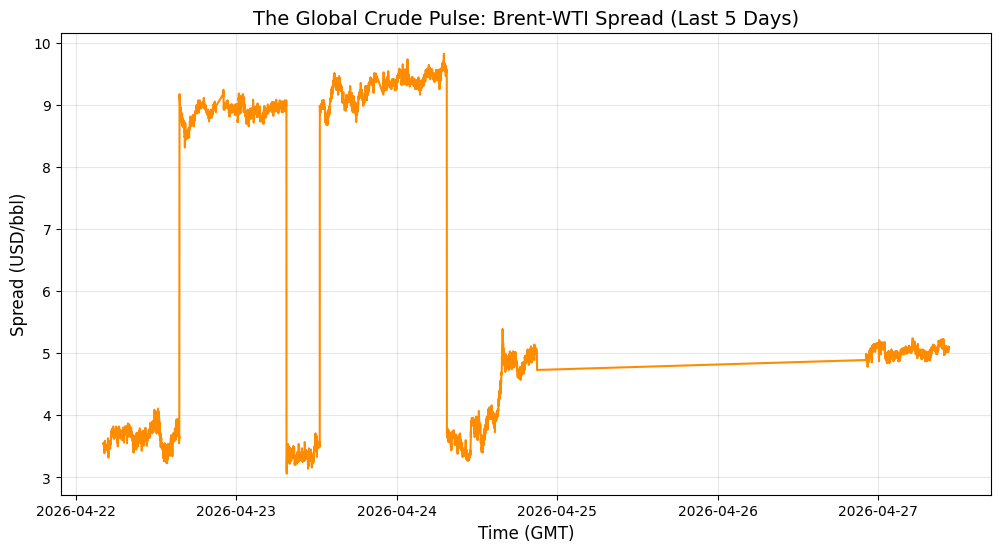

In [7]:
# Set the Style and Size of the Graph
plt.figure(figsize=(12, 6))

# 2. Plot the Spread Column
plt.plot(prices.index, prices['Spread'], color='darkorange', linewidth=1.5)

# 3. Add Labels and Title
plt.title('The Global Crude Pulse: Brent-WTI Spread (Last 5 Days)', fontsize=14)
plt.ylabel('Spread (USD/bbl)', fontsize=12)
plt.xlabel('Time (GMT)', fontsize=12)
plt.grid(True, alpha=0.3)

# 4. Show the Plot
plt.show()

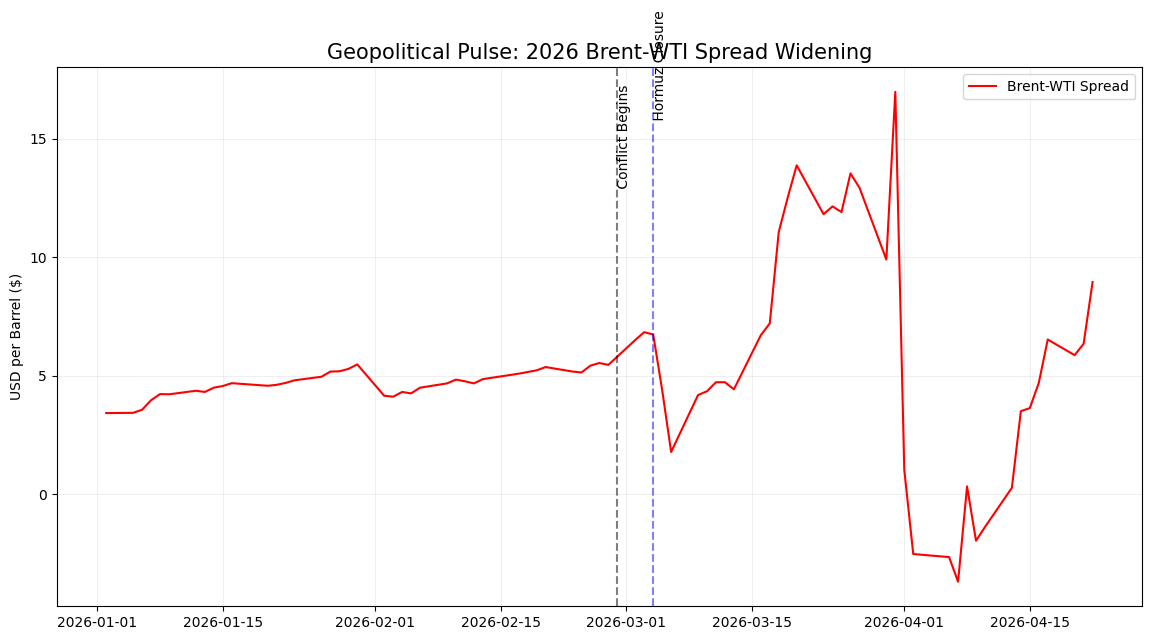

In [8]:
from typing_extensions import TypeVarTuple
# Pull the YTD Data (Jan 1, 2026 to Present)
ytd_wti = yf.download("CL=F", start="2026-01-01", end="2026-04-23", progress=False, auto_adjust = True)
ytd_brent = yf.download("BZ=F", start="2026-01-01", end="2026-04-23", progress=False, auto_adjust = True)

# Combine and Clean
ytd_prices = pd.concat([ytd_wti['Close'], ytd_brent['Close']], axis=1)
ytd_prices.columns = ['WTI', 'Brent']
ytd_prices = ytd_prices.ffill()

# Calculate the Spread
ytd_prices['Spread'] = ytd_prices['Brent'] - ytd_prices['WTI']

# Visualize with Geopolitical Annotations
plt.figure(figsize=(14, 7))
plt.plot(ytd_prices.index, ytd_prices['Spread'], color='red', label='Brent-WTI Spread')

# Adding Geopolitical Markers
plt.axvline(pd.Timestamp('2026-02-28'), color='black', linestyle='--', alpha=0.5)
plt.text(pd.Timestamp('2026-02-28'), 15, ' Conflict Begins', rotation=90, verticalalignment='center')

plt.axvline(pd.Timestamp('2026-03-04'), color='blue', linestyle='--', alpha=0.5)
plt.text(pd.Timestamp('2026-03-04'), 18, ' Hormuz Closure', rotation=90, verticalalignment='center')

plt.title('Geopolitical Pulse: 2026 Brent-WTI Spread Widening', fontsize=15)
plt.ylabel('USD per Barrel ($)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Geopolitical Stress Test of the 2026 Global Energy Market:
1. Automated Ingestion: utilized the 'yfinance' library to pull live, high-frequency market data directly into the environment.
2. Data Alignment & Healing: addressed the "market asynchronicty" problem by using the 'pd.concat' function and '.ffill()' method, which ensures that every minute of WTI data had a corresponding Brent price.
3. Derivative Calculation: engineered a new feature, the Spread (Brent - WTI), which acts as a signle-number indicator of global logistical friction.
4. Contextual Visualization: by mapping price action against the Februrary 28 military escalation and the March 4 Strait of Hormuz closure, transformed raw numbers into a narrative of the 2026 energy crisis.

In commodity markets, "black-swan" events happen during geopolitical shocks. A negative spread means WTI (U.S.) became more expensive than Brent (global), which usually implies a massive local supply squeeze in North America or a total collapse in global shipping demand.

In the context of the current 2026 energy crisis, the latter is true as the Strait of Hormuz closure has upended the supply chain of crude oil.

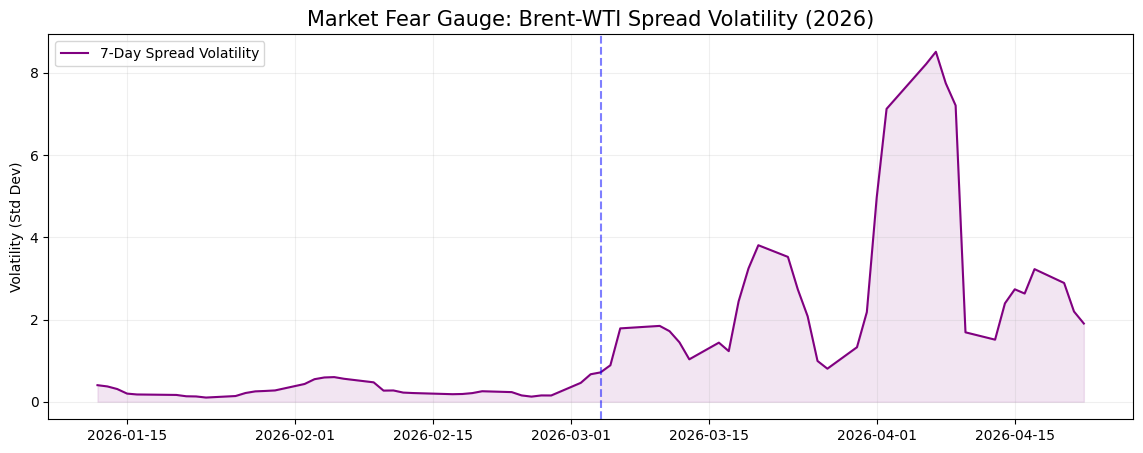

In [9]:
# Calculate the 7-day Rolling volatility of the Spread
ytd_prices['Volatility'] = ytd_prices['Spread'].rolling(window=7).std()

# Visualize the Volatility "Fever Chart"
plt.figure(figsize=(14, 5))
plt.plot(ytd_prices.index, ytd_prices['Volatility'], color='purple', label='7-Day Spread Volatility')

# Annotate the March 4th Hormuz Closure
plt.axvline(pd.Timestamp('2026-03-04'), color='blue', linestyle='--', alpha=0.5)
plt.fill_between(ytd_prices.index, ytd_prices['Volatility'], color='purple', alpha=0.1)

plt.title('Market Fear Gauge: Brent-WTI Spread Volatility (2026)', fontsize=15)
plt.ylabel('Volatility (Std Dev)')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()